# Handling Mixed Data
*When dealing with mixed variables (both numerical and categorical) in feature engineering, strategies involve techniques like one-hot encoding for categorical variables and scaling for numerical ones. These methods ensure compatibility and enhance the effectiveness of mixed variable data in machine learning models.*

## Import Libraries

In [1]:
import numpy as np
import pandas as pd

## Import Dataset from GitHub
So we import the raw dataset from github by url. These dataset made by `CampusX` with the help titanic features.

In [2]:
url = "https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day33-handling-mixed-variables/titanic.csv"

In [3]:
df = pd.read_csv(url)

df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [4]:
df['number'].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

## Splitting a Mixed Variable into Numerical and Categorical  Values from `NUMBER`.

Sometimes a column may contain **both numeric values and text values**. To make this data usable for machine learning models, the column can be separated into two different features: one **numerical** and one **categorical**.

## 1. Extracting the Numerical Values

The `pd.to_numeric()` function is used to convert values into numbers. If a value cannot be converted (for example, text values), it is replaced with `NaN`.

```python
df['number_numerical'] = pd.to_numeric(df['number'], errors='coerce')
```

### Example

| number | number_numerical |
|---|---|
| 10 | 10 |
| 25 | 25 |
| A12 | NaN |
| B | NaN |

Here, `errors='coerce'` ensures that non-numeric values are automatically converted to `NaN`.

## 2. Extracting the Categorical Values

To capture the **non-numeric values**, `np.where()` is used. If the numerical column contains `NaN`, the original value is kept as a categorical value; otherwise it is replaced with `NaN`.

```python
df['number_categorical'] = np.where(
    df['number_numerical'].isnull(),
    df['number'],
    np.nan
)
```

### Example

| number | number_numerical | number_categorical |
|---|---|---|
| 10 | 10 | NaN |
| 25 | 25 | NaN |
| A12 | NaN | A12 |
| B | NaN | B |

## Result

This process creates two separate features:

- **`number_numerical`** → Contains only numeric values
- **`number_categorical`** → Contains only non-numeric (categorical) values

Splitting mixed variables into numerical and categorical components improves data quality and allows machine learning models to process the information more effectively.
```

In [5]:
df['number_numerical'] = pd.to_numeric(df['number'], errors='coerce')
df['number_categorical'] = np.where(df['number_numerical'].isnull(),df['number'], np.nan)
df.head()

,Cabin,Ticket,number,Survived,number_numerical,number_categorical
0,NaN,A/5 21171,5,0,5.0,NaN
1,C85,PC 17599,3,1,3.0,NaN
2,NaN,STON/O2. 3101282,6,1,6.0,NaN
3,C123,113803,3,1,3.0,NaN
4,NaN,373450,A,0,NaN,A


**Observation: Both `Cabin` and `Ticket` contain a large amount of unqiues mixed value in the form of combinations.**

In [6]:
df['Cabin'].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [7]:
df['Ticket'].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

## Cabin Feature Extraction

The `Cabin` column in the Titanic dataset contains both **alphabetical deck information** and **numeric cabin numbers** (e.g., `C85`, `E46`). To make this feature more useful for machine learning models, it is split into two separate features: a **numeric cabin number** and a **categorical cabin deck**.

## 1. Extracting the Cabin Number

The numerical part of the cabin is extracted using a **regular expression**. The pattern `(\d+)` captures one or more digits from the cabin string.

```python
df['cabin_num'] = df['Cabin'].str.extract("(\d+)")
```

### Example

| Cabin | Extracted Number | cabin_num |
|---|---|---|
| C85 | 85 | 85 |
| E46 | 46 | 46 |
| B20 | 20 | 20 |
| NaN | NaN | NaN |

The `str.extract()` method searches the string for digits and returns the matched numeric value.

## 2. Extracting the Cabin Category (Deck)

The first character of the cabin value represents the **deck category**. This is extracted using string indexing.

```python
df['cabin_cat'] = df['Cabin'].str[0]
```


### Example

| Cabin | Extracted Deck | cabin_cat |
|---|---|---|
| C85 | C | C |
| E46 | E | E |
| B20 | B | B |
| NaN | NaN | NaN |

## Result

This process creates two new features:

- **`cabin_num`** → Numeric cabin number
- **`cabin_cat`** → Cabin deck category

Separating the cabin information into numeric and categorical components helps machine learning models capture patterns related to **passenger location on the ship**, which may influence survival outcomes.

In [8]:
df['cabin_num'] = df['Cabin'].str.extract("(\d+)") # captures numerical part
df['cabin_cat'] = df['Cabin'].str[0]

df.head(5)

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


<Axes: xlabel='cabin_cat'>

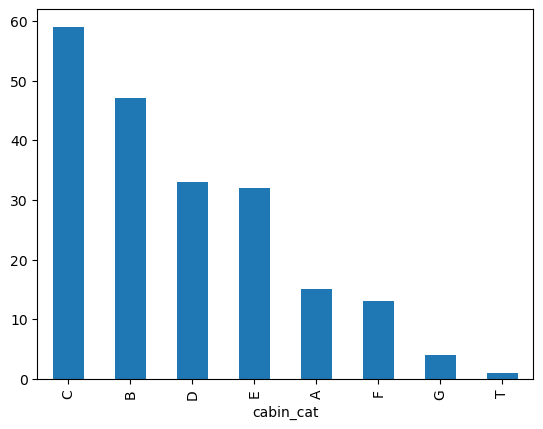

In [9]:
df['cabin_cat'].value_counts().plot(kind='bar')

**Observation: Now we see the unique value of `cabin` is manageble and short as compare to before values.**

## Ticket Feature Extraction

The `Ticket` column in the Titanic dataset contains both **categorical prefixes** and **numeric identifiers**. To make this feature more useful for machine learning models, the column is split into two separate features: a **numeric ticket number** and a **categorical ticket prefix**.

## 1. Extracting the Ticket Number

The last part of the ticket string is extracted using `split()` and stored in a new column called `ticket_num`.

```python
df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])
```

### Example

| Ticket | split() result | last element |
|---|---|---|
| `A/5 21171` | `['A/5','21171']` | `21171` |
| `PC 17599` | `['PC','17599']` | `17599` |
| `347082` | `['347082']` | `347082` |

After extraction, the values are converted into numeric format using `pd.to_numeric()`. If a value cannot be converted, it is replaced with `NaN`.

```python
df['ticket_num'] = pd.to_numeric(df['ticket_num'], errors='coerce', downcast='integer')
```

### Example (After Conversion)

| Ticket | ticket_num |
|---|---|
| A/5 21171 | 21171 |
| PC 17599 | 17599 |
| 347082 | 347082 |


## 2. Extracting the Ticket Category

The first part of the ticket string is extracted to capture the **ticket prefix**, which may indicate booking groups or ticket types.

```python
df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])
```

If the extracted value contains only digits, it means the ticket does not have a prefix. In such cases, the value is replaced with `NaN`.

```python
df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan, df['ticket_cat'])
```

### Example

| Ticket | Extracted Prefix | ticket_cat |
|---|---|---|
| A/5 21171 | A/5 | A/5 |
| PC 17599 | PC | PC |
| 347082 | 347082 | NaN |

## Result

This process creates two new features:

- **`ticket_num`** → Numeric component of the ticket
- **`ticket_cat`** → Categorical prefix of the ticket (if present)

Separating the ticket into numeric and categorical parts improves feature usability and helps machine learning models capture patterns related to **ticket groups or booking categories**.

In [10]:
#extract the last bit of tickets as number

df['ticket_num'] = df['Ticket'].apply(lambda s: s.split()[-1])

df['ticket_num'] = pd.to_numeric(df['ticket_num'], errors='coerce', downcast='integer')


#extract the last bit of tickets as categoy

df['ticket_cat'] = df['Ticket'].apply(lambda s: s.split()[0])

df['ticket_cat'] = np.where(df['ticket_cat'].str.isdigit(), np.nan,
                            df['ticket_cat'])

df.head(10)

,Cabin,Ticket,number,Survived,number_numerical,number_categorical,cabin_num,cabin_cat,ticket_num,ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
5,NaN,330877,2,0,2.0,NaN,NaN,NaN,330877.0,NaN
6,E46,17463,2,0,2.0,NaN,46,E,17463.0,NaN
7,NaN,349909,5,0,5.0,NaN,NaN,NaN,349909.0,NaN
8,NaN,347742,1,1,1.0,NaN,NaN,NaN,347742.0,NaN
9,NaN,237736,A,1,NaN,A,NaN,NaN,237736.0,NaN
